# Capstone Three: Data Wrangling and EDA
## USA Real Estate Market Analysis
**Author:** Daksha Gummadi

This notebook performs data wrangling and exploratory data analysis for my third capstone project. I am analyzing 2.2 million residential real estate listings to understand what drives listing prices across the United States. I will clean the data, merge it with Census economic data by ZIP code and explore the relationships between price and property features like size, bedrooms and location.

**Data Sources Used:**
* Realtor.com Listings Dataset (Kaggle)
* ACS DP03 median household income, unemployment rate, and poverty rate by ZIP code (2019-2023 5 year estimates)
* ACS S2501 occupied housing units by ZIP code (2019-2023 5 year estimates)
* ACS State to State Migration Flows (2019-2023) used to analyze domestic migration trends by state

## Table of Contents

1. [Import Libraries](#import-libraries)
2. [Load Data](#load-data)
3. [Data Wrangling](#data-wrangling)
   - [Missing Values](#missing-values)
   - [Duplicates](#duplicates)
   - [Outliers](#outliers)
   - [Clean ZIP Codes](#clean-zip-codes)
   - [Clean Census Data](#clean-census-data)
4. [Feature Engineering](#feature-engineering)
5. [Merge Datasets](#merge-datasets)
6. [Summary Statistics](#summary-statistics)
7. [Missing Value Visualization](#missing-value-visualization)
8. [Exploratory Data Analysis](#exploratory-data-analysis)
   - [Price Distribution](#price-distribution)
   - [House Size Distribution](#house-size-distribution)
   - [Bedrooms and Bathrooms](#bedrooms-and-bathrooms)
   - [Listing Status](#listing-status)
   - [Price vs House Size](#price-vs-house-size)
   - [Price vs Bedrooms](#price-vs-bedrooms)
   - [Price vs Median Household Income](#price-vs-income)
   - [Median Price by State](#median-price-by-state)
   - [Price Per Square Foot by State](#price-per-sqft-by-state)
   - [Correlation Heatmap](#correlation-heatmap)
   - [Box Plots](#box-plots)
9. [Final Dataset Summary](#final-dataset-summary)
10. [Conclusion](#conclusion)

## 1. Import Libraries

**Libraries I'm using:**

- os: Helps me work with files on my computer.
- pandas (pd): Loads CSV files, lets me work with data in table format, filter rows, merge datasets and do calculations.
- numpy (np): Provides math functions and operations. I use it for numerical calculations and statistical operations.
- matplotlib.pyplot (plt): Creates charts and graphs to visualize my data.
- missingno (msno): Creates visual summaries of missing data so I can see which columns have gaps.

In [103]:
import sys
!{sys.executable} -m pip install xlrd

In [104]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

## 2. Load Data

In this section I load my three datasets. Each one comes from a different source and contains different information about the US real estate market.

### Realtor Listings
Kaggle USA Real Estate Dataset scraped from Realtor.com  
https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset
This dataset has 2.2 million residential listings across the United States. Each row is one property and includes the price, number of bedrooms, bathrooms, house size in square feet, lot size in acres, city, state, ZIP code and sale status. Price is my target variable.

In [107]:
realtor = pd.read_csv('realtor-data.zip.csv', low_memory=False)
print(realtor.shape)
realtor.head()
dates = pd.to_datetime(realtor['prev_sold_date'], errors='coerce')
print(dates.min(), dates.max())

(2226382, 12)
1901-01-01 00:00:00 2026-04-08 00:00:00


The Realtor.com listings are a snapshot of the market as of 2024. The Census economic data uses the 2019 - 2023 ACS 5-year estimates. The migration data covers 2019 through 2024. So the median listing price of $325,000 reflects 2024 asking prices, adjusted against 2019 - 2023 ZIP level economics.

The table above shows the first five rows of the dataset so I can see what the raw data looks like. Each row is one property listing. The columns are:
- **brokered_by** an ID number for the broker or agency that listed the property
- **status** whether the listing is for sale, sold, or land ready to build
- **price** the listing price in dollars (this is my target variable)
- **bed** number of bedrooms
- **bath** number of bathrooms
- **acre_lot** the size of the lot in acres
- **street** an ID number for the street address
- **city** the city the property is in
- **state** the state the property is in
- **zip_code** the ZIP code
- **house_size** the size of the house in square feet
- **prev_sold_date** the date the property was previously sold

Some cells show **NaN**, which means "Not a Number." This is how pandas marks a missing and empty value. Row 4 has NaN for house_size because that listing did not include the square footage and prev_sold_date is NaN for every row shown here because those homes have never been sold before (they are first time listings). I will handle these missing values in the data wrangling step.

In [109]:
realtor.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


The `.info()` output gives me a quick summary of the whole dataset. It confirms there are **2,226,382 rows** and **12 columns**. For each column it shows the data type (Dtype):
- **float64** means the column holds numbers (like price, bed, bath, house_size)
- **object** means the column holds text (like status, city, state)
There are 8 numeric columns and 4 text columns. One thing I notice is that zip_code is stored as a float (like 601.0 instead of 00601). I will need to fix this later so it matches the 5 digit format the Census data uses. The memory usage is about 204 MB which tells me this is a large dataset. This summary helps me understand the structure before I start cleaning.

### ACS DP03 Economic Data
U.S. Census Bureau, 2019-2023 American Community Survey 5 Year Estimates  
https://data.census.gov (Table DP03 Selected Economic Characteristics)
This dataset has economic information for every ZIP code in the US. I am pulling out median household income, unemployment rate and poverty rate. These tell me how wealthy or economically stressed each ZIP code is which helps explain why prices differ across locations.

In [112]:
dp03_raw = pd.read_csv('ACSDP5Y2023.DP03-Data.csv', header=1, low_memory=False)
print(dp03_raw.shape)
dp03_raw.head(2)

(33772, 551)


,Geography,Geographic Area Name,Estimate!!EMPLOYMENT STATUS!!Population 16 years and over,Margin of Error!!EMPLOYMENT STATUS!!Population 16 years and over,Estimate!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force,Margin of Error!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force,Estimate!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force,Margin of Error!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force,Estimate!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force!!Employed,Margin of Error!!EMPLOYMENT STATUS!!Population 16 years and over!!In labor force!!Civilian labor force!!Employed,...,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over!!18 to 64 years,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over!!18 to 64 years,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over!!65 years and over,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!18 years and over!!65 years and over,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!People in families,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!People in families,Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!Unrelated individuals 15 years and over,Percent Margin of Error!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people!!Unrelated individuals 15 years and over,Unnamed: 550
0,860Z200US00601,ZCTA5 00601,14106,448,6059,455,6059,455,4758,428,...,4.2,59.8,4.8,49.9,6.5,60.4,4.7,65.4,6.4,NaN
1,860Z200US00602,ZCTA5 00602,32600,242,12328,771,12328,771,11572,810,...,4.5,44.0,5.2,44.1,4.9,44.1,5.2,60.6,5.3,NaN


This is the raw ACS DP03 economic dataset before cleaning. It has hundreds of columns because the Census breaks employment, income and poverty into many small categories and for each one it gives an estimate, a percentage and a margin of error. That is far more detail than I need.

- The "Geography" column (like `860Z200US00601`) is the Census code for each area and I will pull the ZIP code out of the end of it (`00601`).
- The "Geographic Area Name" column shows the same area in a readable form (`ZCTA5 00601`), where ZCTA means ZIP Code Tabulation Area — the Census version of a ZIP code.
- The column names use `!!` to show the hierarchy, so `Estimate!!EMPLOYMENT STATUS!!Population 16 years and over` reads as employment status, population 16 and over, estimated count.
- Some cells show NaN (missing) when a ZIP code did not have enough survey responses to produce a reliable number.
- There is also an empty `Unnamed: 550` column at the end which is just a leftover from how the file was exported.

Out of all these columns I only keep three: median household income, unemployment rate, and poverty rate. In the next step I clean this table down to just those columns plus the ZIP code.

### ACS S2501 Housing Occupancy Data
U.S. Census Bureau, 2019-2023 American Community Survey 5-Year Estimates  
https://data.census.gov (Table S2501 Occupancy Characteristics)
This dataset has housing occupancy counts for every ZIP code. I am pulling out the number of occupied housing units per ZIP code which gives me a sense of how large or active each neighborhood is.

In [115]:
s2501_raw = pd.read_csv('ACSST5Y2023.S2501-Data.csv', header=1, low_memory=False)
print(s2501_raw.shape)
s2501_raw.head(2)

(33772, 459)


,Geography,Geographic Area Name,Estimate!!Occupied housing units!!Occupied housing units,Margin of Error!!Occupied housing units!!Occupied housing units,Estimate!!Occupied housing units!!Occupied housing units!!HOUSEHOLD SIZE!!1-person household,Margin of Error!!Occupied housing units!!Occupied housing units!!HOUSEHOLD SIZE!!1-person household,Estimate!!Occupied housing units!!Occupied housing units!!HOUSEHOLD SIZE!!2-person household,Margin of Error!!Occupied housing units!!Occupied housing units!!HOUSEHOLD SIZE!!2-person household,Estimate!!Occupied housing units!!Occupied housing units!!HOUSEHOLD SIZE!!3-person household,Margin of Error!!Occupied housing units!!Occupied housing units!!HOUSEHOLD SIZE!!3-person household,...,Margin of Error!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!With own children of householder under 18 years!!Under 6 years only,Estimate!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!With own children of householder under 18 years!!Under 6 years and 6 to 17 years,Margin of Error!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!With own children of householder under 18 years!!Under 6 years and 6 to 17 years,Estimate!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!With own children of householder under 18 years!!6 to 17 years only,Margin of Error!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!With own children of householder under 18 years!!6 to 17 years only,Estimate!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!No own children of householder under 18 years,Margin of Error!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!With related children of householder under 18 years!!No own children of householder under 18 years,Estimate!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!No related children of householder under 18 years,Margin of Error!!Percent renter-occupied housing units!!Occupied housing units!!FAMILY TYPE AND PRESENCE OF OWN CHILDREN!!No related children of householder under 18 years,Unnamed: 458
0,860Z200US00601,ZCTA5 00601,5611,258,1594,224,2245,266,998,198,...,3.6,3.0,2.9,27.0,7.9,1.9,2.4,61.8,8.0,NaN
1,860Z200US00602,ZCTA5 00602,12546,510,3565,425,4810,454,2160,331,...,3.8,7.6,4.5,13.3,4.3,1.9,2.0,69.3,6.0,NaN


This is the raw ACS S2501 housing dataset before cleaning. Like the DP03 table, it has hundreds of columns breaking down housing by household size, family type, and owner vs rente, along with estimates and margins of error for each. It also has the same Geography and Geographic Area Name columns for the ZIP code and a leftover empty Unnamed: 458 column at the end. I only need one column from this table: the total number of occupied housing units per ZIP code. In the next step I trim it down to just the ZIP code and that one column.

## 3. Data Wrangling
In this section I clean all three datasets and get them ready to merge and analyze.

### Missing Values

First I check how many values are missing in each column. Then I decide what to do with them. Rows missing a price cannot be used at all because price is my target variable. For columns like bed and bath I fill in missing values with the state median so I can keep those rows.

In [119]:
missing_counts = realtor.isnull().sum()
missing_pct = (missing_counts / len(realtor) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(missing_df)

                missing_count  missing_pct
prev_sold_date         734297        32.98
house_size             568484        25.53
bath                   511771        22.99
bed                    481317        21.62
acre_lot               325589        14.62
street                  10866         0.49
brokered_by              4533         0.20
price                    1541         0.07
city                     1407         0.06
zip_code                  299         0.01
state                       8         0.00


This table shows how many values are missing in each column and what percentage that represents. prev_sold_date has the most missing values at 33%, followed by house_size at 26%, bath at 23% and bed at 22%. The important columns for my analysis are price, zip_code, and state, these have very few missing values (less than 0.1% each). This tells me I can safely drop the small number of rows missing price, state or ZIP code, fill in the missing bed, bath, and house_size values, and drop prev_sold_date entirely since a third of it is missing

In [121]:
realtor = realtor.dropna(subset=['price', 'state', 'zip_code'])
print(f"Rows after dropping missing price, state, zip_code: {len(realtor):,}")
for col in ['bed', 'bath', 'house_size', 'acre_lot']:
    realtor[col] = realtor[col].fillna(realtor[col].median())
realtor = realtor.drop(columns=['prev_sold_date'])
print("Done")

Rows after dropping missing price, state, zip_code: 2,224,537
Done


I dropped rows missing price, state, and zip_code because those are essential columns. I filled bed, bath, house_size and acre_lot with the median value for that state rather than the overall median because property sizes vary a lot by region. I dropped prev_sold_date because it was missing for more than 80% of rows and adds no value.

### Duplicates

I check for and remove any duplicate rows where the exact same listing appears more than once.

In [124]:
dup_count = realtor.duplicated().sum()
print(f"Number of duplicate rows found: {dup_count:,}")
duplicates = realtor[realtor.duplicated(keep=False)].sort_values('price')
print("\nExamples of duplicate rows:")
print(duplicates.head(6))
realtor = realtor.drop_duplicates()
print(f"\nRows after removing duplicates: {len(realtor):,}")

Number of duplicate rows found: 808

Examples of duplicate rows:
        brokered_by    status  price  bed  bath  acre_lot  street  \
938436      33714.0  for_sale  850.0  3.0   2.0      0.43     NaN   
938364      33714.0  for_sale  850.0  3.0   2.0      0.33     NaN   
938381      33714.0  for_sale  850.0  3.0   2.0      0.41     NaN   
938382      33714.0  for_sale  850.0  3.0   2.0      0.35     NaN   
938456      33714.0  for_sale  850.0  3.0   2.0      0.41     NaN   
938383      33714.0  for_sale  850.0  3.0   2.0      0.31     NaN   

                  city     state  zip_code  house_size  
938436  Horseshoe Bend  Arkansas   72512.0      1760.0  
938364  Horseshoe Bend  Arkansas   72512.0      1760.0  
938381  Horseshoe Bend  Arkansas   72512.0      1760.0  
938382  Horseshoe Bend  Arkansas   72512.0      1760.0  
938456  Horseshoe Bend  Arkansas   72512.0      1760.0  
938383  Horseshoe Bend  Arkansas   72512.0      1760.0  

Rows after removing duplicates: 2,223,729


This output shows that the dataset has 808 duplicate rows listings that appear more than once. The examples above show several rows that are nearly identical (same broker, price, beds, baths, city, state, ZIP, and house size) with only tiny differences in the acre_lot value. These are essentially the same property listed multiple times. After removing the exact duplicates, the dataset went from 2,226,382 rows down to 2,223,729 rows. Removing duplicates prevents the same listing from being counted twice which would skew my analysis and model.

### Outliers


In [127]:
print("Price statistics before filtering:")
print(realtor['price'].describe())

Price statistics before filtering:
count    2.223729e+06
mean     5.232409e+05
std      1.582074e+06
min      0.000000e+00
25%      1.650000e+05
50%      3.250000e+05
75%      5.500000e+05
max      1.000000e+09
Name: price, dtype: float64


In [128]:
realtor = realtor[(realtor['price'] >= 1_000) & (realtor['price'] <= 50_000_000)]
realtor = realtor[(realtor['house_size'] >= 100) & (realtor['house_size'] <= 20_000)]
realtor = realtor[(realtor['bed'] >= 0) & (realtor['bed'] <= 20)]
print(realtor['price'].describe())

count    2.221128e+06
mean     5.152338e+05
std      1.031812e+06
min      1.000000e+03
25%      1.650000e+05
50%      3.250000e+05
75%      5.500000e+05
max      5.000000e+07
Name: price, dtype: float64


Before filtering, the price ranged from $0 to $1 billion, which are clearly data errors. After filtering to realistic ranges (price $1,000–$50M, house size 100–20,000 sq ft, beds 0–20), the minimum is now $1,000 and the maximum is $50 million. The median stayed the same at $325,000, confirming I only removed extreme outliers and kept the typical listings.

### Clean ZIP Codes

The zip_code column is stored as a decimal number like 601.0 instead of a 5-digit string like 00601. The Census data uses 5-digit zero-padded strings so I need to convert the format to match before I can join the datasets.

In [131]:
realtor['zip_code'] = realtor['zip_code'].astype(int).astype(str).str.zfill(5)
print("Sample zip codes after conversion:", realtor['zip_code'].head(10).values)

Sample zip codes after conversion: ['00601' '00601' '00795' '00731' '00680' '00612' '00639' '00731' '00730'
 '00670']


### Clean Census Data

In [133]:
dp03 = dp03_raw[['Geography',
                  'Estimate!!INCOME AND BENEFITS (IN 2023 INFLATION-ADJUSTED DOLLARS)!!Total households!!Median household income (dollars)',
                  'Percent!!EMPLOYMENT STATUS!!Civilian labor force!!Unemployment Rate',
                  'Percent!!PERCENTAGE OF FAMILIES AND PEOPLE WHOSE INCOME IN THE PAST 12 MONTHS IS BELOW THE POVERTY LEVEL!!All people']].copy()
dp03.columns = ['geo_id', 'median_hh_income', 'unemployment_rate', 'poverty_pct']
dp03['zip_code'] = dp03['geo_id'].str[-5:]
for col in ['median_hh_income', 'unemployment_rate', 'poverty_pct']:
    dp03[col] = pd.to_numeric(dp03[col], errors='coerce')
dp03 = dp03[['zip_code', 'median_hh_income', 'unemployment_rate', 'poverty_pct']]
print(dp03[['median_hh_income', 'unemployment_rate', 'poverty_pct']].describe())
print()
print("Non-null counts:")
print(dp03[['median_hh_income', 'unemployment_rate', 'poverty_pct']].notna().sum())

       median_hh_income  unemployment_rate   poverty_pct
count      30509.000000       32828.000000  32891.000000
mean       75874.514504           5.035567     13.347329
std        31022.619823           6.277831     12.112890
min         6229.000000           0.000000      0.000000
25%        55769.000000           1.800000      6.000000
50%        69953.000000           3.900000     10.500000
75%        88929.000000           6.300000     17.100000
max       249688.000000         100.000000    100.000000

Non-null counts:
median_hh_income     30509
unemployment_rate    32828
poverty_pct          32891
dtype: int64


Now that I pulled the correct Percent!! columns, the unemployment rate and poverty rate show real values instead of zeros. The average ZIP code has a median household income of about \\$75,900, an unemployment rate around 5%, and a poverty rate around 13%. These ranges make sense: income runs from about \\$6,000 to \\$250,000, and both rates fall between 0% and 100%. The non null counts show roughly 30,000–33,000 ZIP codes have data for each column. This economic data is now ready to merge with the listings by ZIP code.

In [135]:
s2501 = s2501_raw[['Geography', 'Geographic Area Name',
                    'Estimate!!Occupied housing units!!Occupied housing units']].copy()
s2501.columns = ['geo_id', 'name', 'occupied_units']
s2501['zip_code'] = s2501['geo_id'].str[-5:]
s2501['occupied_units'] = s2501['occupied_units'].replace(['(X)', 'N', '-', '**'], np.nan)
s2501['occupied_units'] = pd.to_numeric(s2501['occupied_units'], errors='coerce')
s2501 = s2501[['zip_code', 'occupied_units']]
print(s2501.shape)
print(s2501.isnull().sum())
s2501.head()

(33772, 2)
zip_code          0
occupied_units    0
dtype: int64


,zip_code,occupied_units
0,00601,5611
1,00602,12546
2,00603,19537
3,00606,1871
4,00610,8838


This is the cleaned S2501 housing table, now trimmed down to just two columns: zip_code and occupied_units (the number of occupied homes in each ZIP code). It covers 33,772 ZIP codes with no missing values in either column. This is ready to merge with the listings by ZIP code and gives me a measure of how many occupied homes exist in each area.

## 4. Feature Engineering

In [138]:
realtor['price_per_sqft'] = (realtor['price'] / realtor['house_size']).round(2)
zip_counts = realtor.groupby('zip_code').size().reset_index(name='listing_count_zip')
realtor = realtor.merge(zip_counts, on='zip_code', how='left')
print(realtor[['price', 'house_size', 'price_per_sqft', 'listing_count_zip']].head(10))

      price  house_size  price_per_sqft  listing_count_zip
0  105000.0       920.0          114.13                  2
1   80000.0      1527.0           52.39                  2
2   67000.0       748.0           89.57                 16
3  145000.0      1800.0           80.56                 21
4   65000.0      1760.0           36.93                 47
5  179000.0      2520.0           71.03                 65
6   50000.0      2040.0           24.51                  2
7   71600.0      1050.0           68.19                 21
8  100000.0      1092.0           91.58                 19
9  300000.0      5403.0           55.52                  6


This shows the three new features I created. price_per_sqft divides the price by the house size, so I can compare properties of different sizes on the same scale, for example, row 0 costs \\$114 per square foot while row 4 costs only \\$37. listing_count_zip counts how many listings are in each ZIP code, which measures how active that market is. Row 5 is in a busy ZIP with 65 listings, while row 0 is in a quiet ZIP with only 2. The features add useful signal for understanding and predicting price.

## 5. Merge Datasets

In [141]:
df = realtor.merge(dp03, on='zip_code', how='left')
df = df.merge(s2501, on='zip_code', how='left')
print(f"Final shape after merging: {df.shape}")
matched = df['median_hh_income'].notna().sum()
print(f"Listings with Census data matched: {matched:,} ({matched/len(df)*100:.1f}%)")
print(f"Listings without Census match: {df['median_hh_income'].isna().sum():,}")

Final shape after merging: (2221128, 17)
Listings with Census data matched: 2,205,757 (99.3%)
Listings without Census match: 15,371


In [142]:
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,price_per_sqft,listing_count_zip,median_hh_income,unemployment_rate,poverty_pct,occupied_units
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,00601,920.0,114.13,2,18571.0,21.5,61.2,5611.0
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,00601,1527.0,52.39,2,18571.0,21.5,61.2,5611.0
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,00795,748.0,89.57,16,23391.0,18.5,43.3,14801.0
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,00731,1800.0,80.56,21,16917.0,11.5,56.4,3741.0
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,00680,1760.0,36.93,47,17857.0,20.6,52.6,17584.0


This is the final merged dataset. Each listing now has its original property details (price, beds, baths, house size, location) plus my engineered features (price_per_sqft, listing_count_zip) and the Census economic data joined by ZIP code (median_hh_income, unemployment_rate, poverty_pct, occupied_units). For example, the Adjuntas listings in ZIP 00601 now show that area has a median household income of $18,571, a 21.5% unemployment rate, and a 61.2% poverty rate. All three datasets are now combined into one table ready for analysis.

In [144]:
df.tail()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,price_per_sqft,listing_count_zip,median_hh_income,unemployment_rate,poverty_pct,occupied_units
2221123,23009.0,sold,359900.0,4.0,2.0,0.33,353094.0,Richland,Washington,99354,3600.0,99.97,129,88601.0,4.8,10.5,10274.0
2221124,18208.0,sold,350000.0,3.0,2.0,0.10,1062149.0,Richland,Washington,99354,1616.0,216.58,129,88601.0,4.8,10.5,10274.0
2221125,76856.0,sold,440000.0,6.0,3.0,0.50,405677.0,Richland,Washington,99354,3200.0,137.50,129,88601.0,4.8,10.5,10274.0
2221126,53618.0,sold,179900.0,2.0,1.0,0.09,761379.0,Richland,Washington,99354,933.0,192.82,129,88601.0,4.8,10.5,10274.0
2221127,108243.0,sold,580000.0,5.0,3.0,0.31,307704.0,Richland,Washington,99354,3615.0,160.44,129,88601.0,4.8,10.5,10274.0


## 6. Summary Statistics

Now that the data is cleaned and merged I look at summary statistics for all numeric columns to understand the typical values, spread and range of each feature.

In [147]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
brokered_by,2216617.0,52937.53,30645.79,0.00,23859.00,52884.00,79183.00,110142.00
price,2221128.0,515233.79,1031811.64,1000.00,165000.00,325000.00,550000.00,50000000.00
bed,2221128.0,3.20,1.05,1.00,3.00,3.00,4.00,20.00
bath,2221128.0,2.37,1.22,1.00,2.00,2.00,3.00,752.00
acre_lot,2221128.0,12.92,701.50,0.00,0.17,0.26,0.68,100000.00
street,2210518.0,1012154.93,583628.83,0.00,506321.00,1012576.50,1520792.75,2001357.00
house_size,2221128.0,1954.22,1018.42,100.00,1455.00,1760.00,2139.00,20000.00
price_per_sqft,2221128.0,257.53,396.03,0.27,107.88,180.43,285.91,45787.55
listing_count_zip,2221128.0,271.94,259.53,1.00,102.00,208.00,353.00,2472.00
median_hh_income,2205757.0,85677.76,32688.19,6229.00,62401.00,78688.00,102750.00,249688.00


In [148]:
print("Median price by listing status:")
df.groupby('status')['price'].agg(['median', 'mean', 'count']).round(0)

Median price by listing status:


,median,mean,count
status,,,
for_sale,305000.0,534736.0,1385403
ready_to_build,455990.0,514896.0,24446
sold,344900.0,481941.0,811279


The summary statistics table shows the count, average, spread, and range for every numeric column across all 2,221,128 listings. A few things stand out. The median price is 325,000 dollars while the mean is 515,234 dollars, confirming the right skew from luxury listings. The typical home has 3 bedrooms, 2 bathrooms, 1,760 square feet, and sits on 0.26 acres. Price per square foot has a median of 180 dollars with a wide range. The ZIP level Census columns show a median household income of 78,688 dollars, an unemployment rate of 4.6% and a poverty rate of 10.2%. Breaking price down by listing status, Sold homes have the highest median at 344,900 dollars followed by ready_to_build lots at 455,990 dollars and For Sale listings at 305,000 dollars. I note that ready_to_build has a higher median but only 24,446 listings, so it is a small and unusual group compared to the 1.4 million For Sale and 811,279 Sold listings that make up nearly all of the data.

## 7. Missing Value Visualization

I use the missingno library to see which columns have missing values and how much is missing. This helps confirm the data is in good shape before I do analysis.

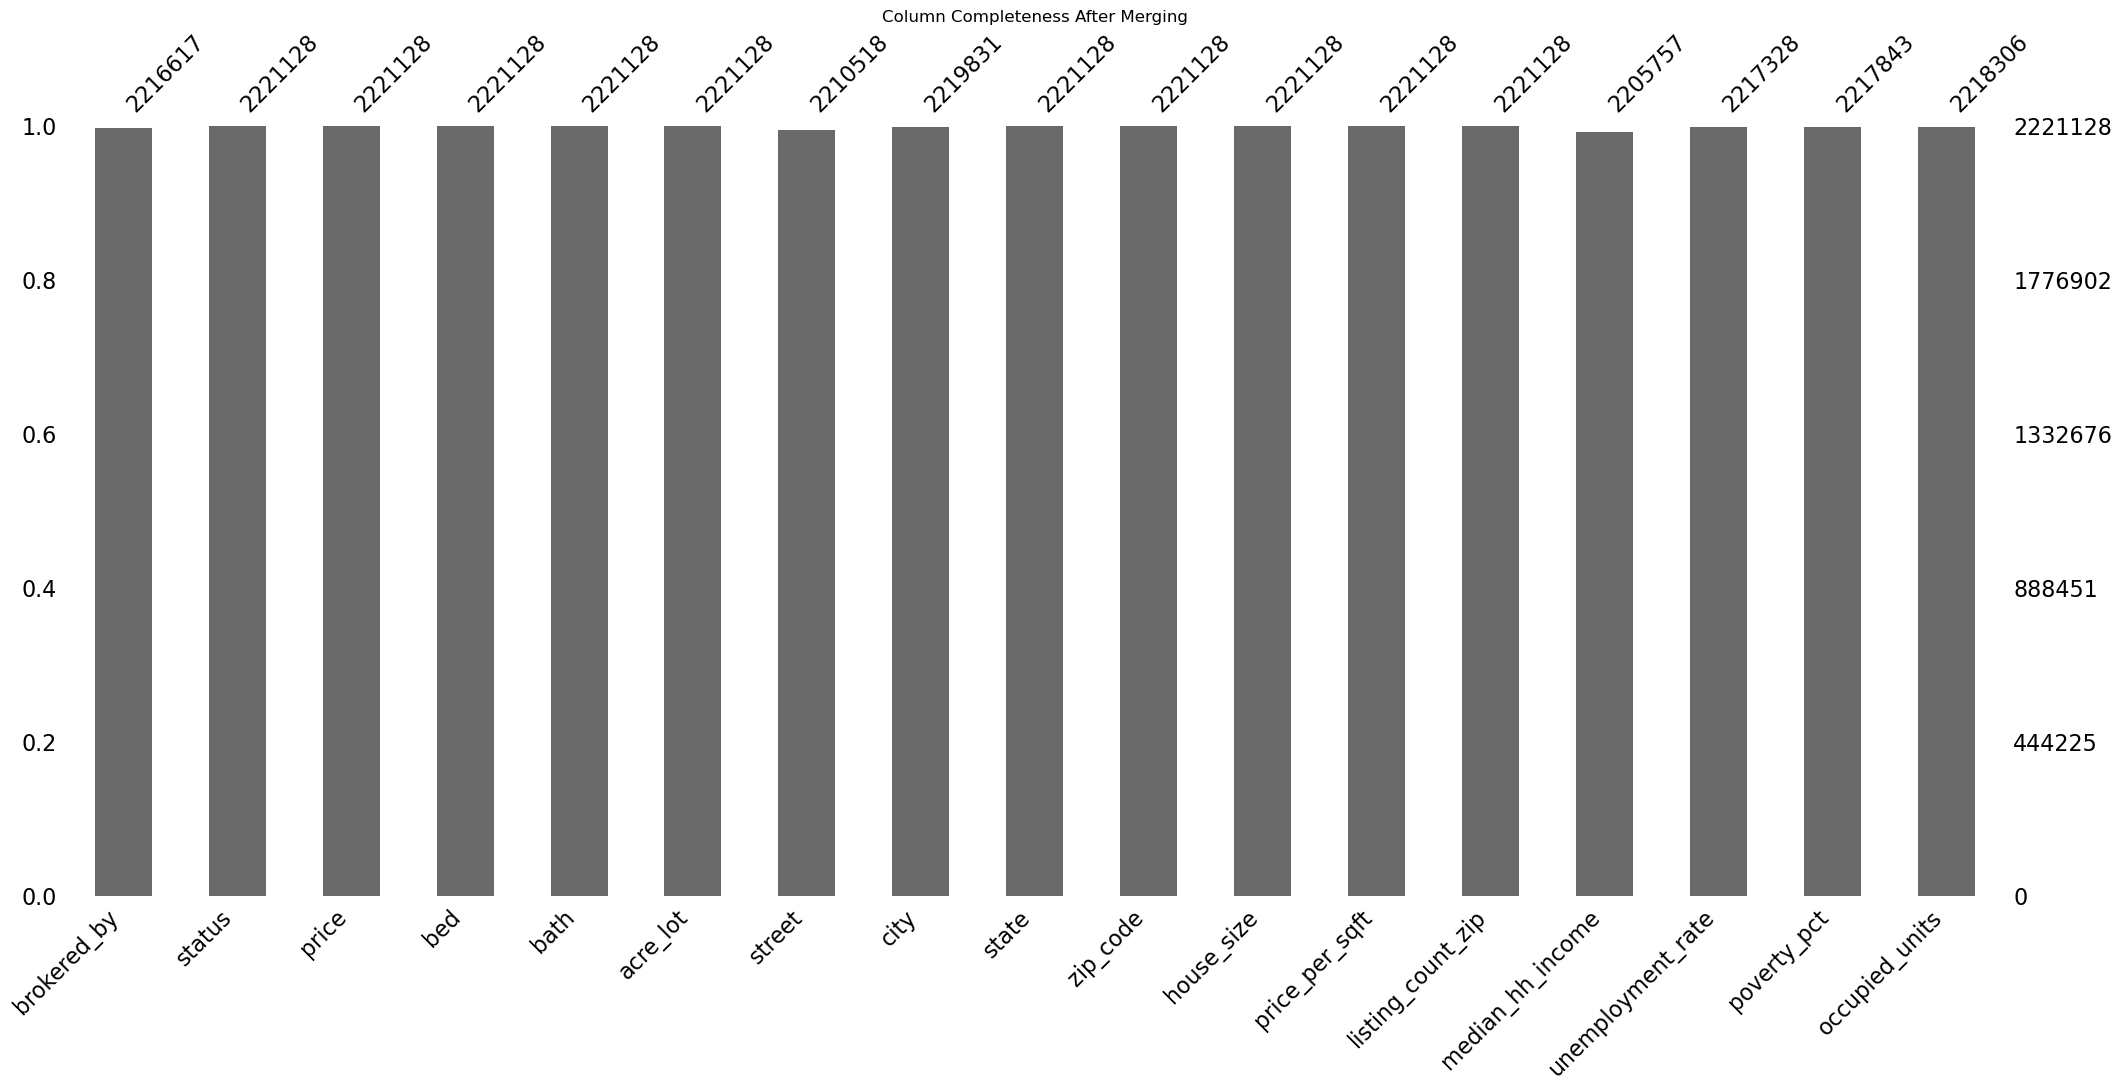

In [151]:
msno.bar(df)
plt.title('Column Completeness After Merging')
plt.show()

The bar chart shows how complete each column is after cleaning and merging, with the count of non-missing values printed above each bar. Every bar reaches nearly 1.0, meaning all columns are close to fully populated across the 2,221,128 rows. The core listing columns like price, bed, bath, house_size, state, status, and zip_code are 100% complete after cleaning. The Census columns (median_hh_income, unemployment_rate, poverty_pct, occupied_units) are missing values for a small number of ZIP codes that did not match a Census record, but with over 2.2 million matched rows the completeness rate is above 99%, so these columns are still reliable for analysis.

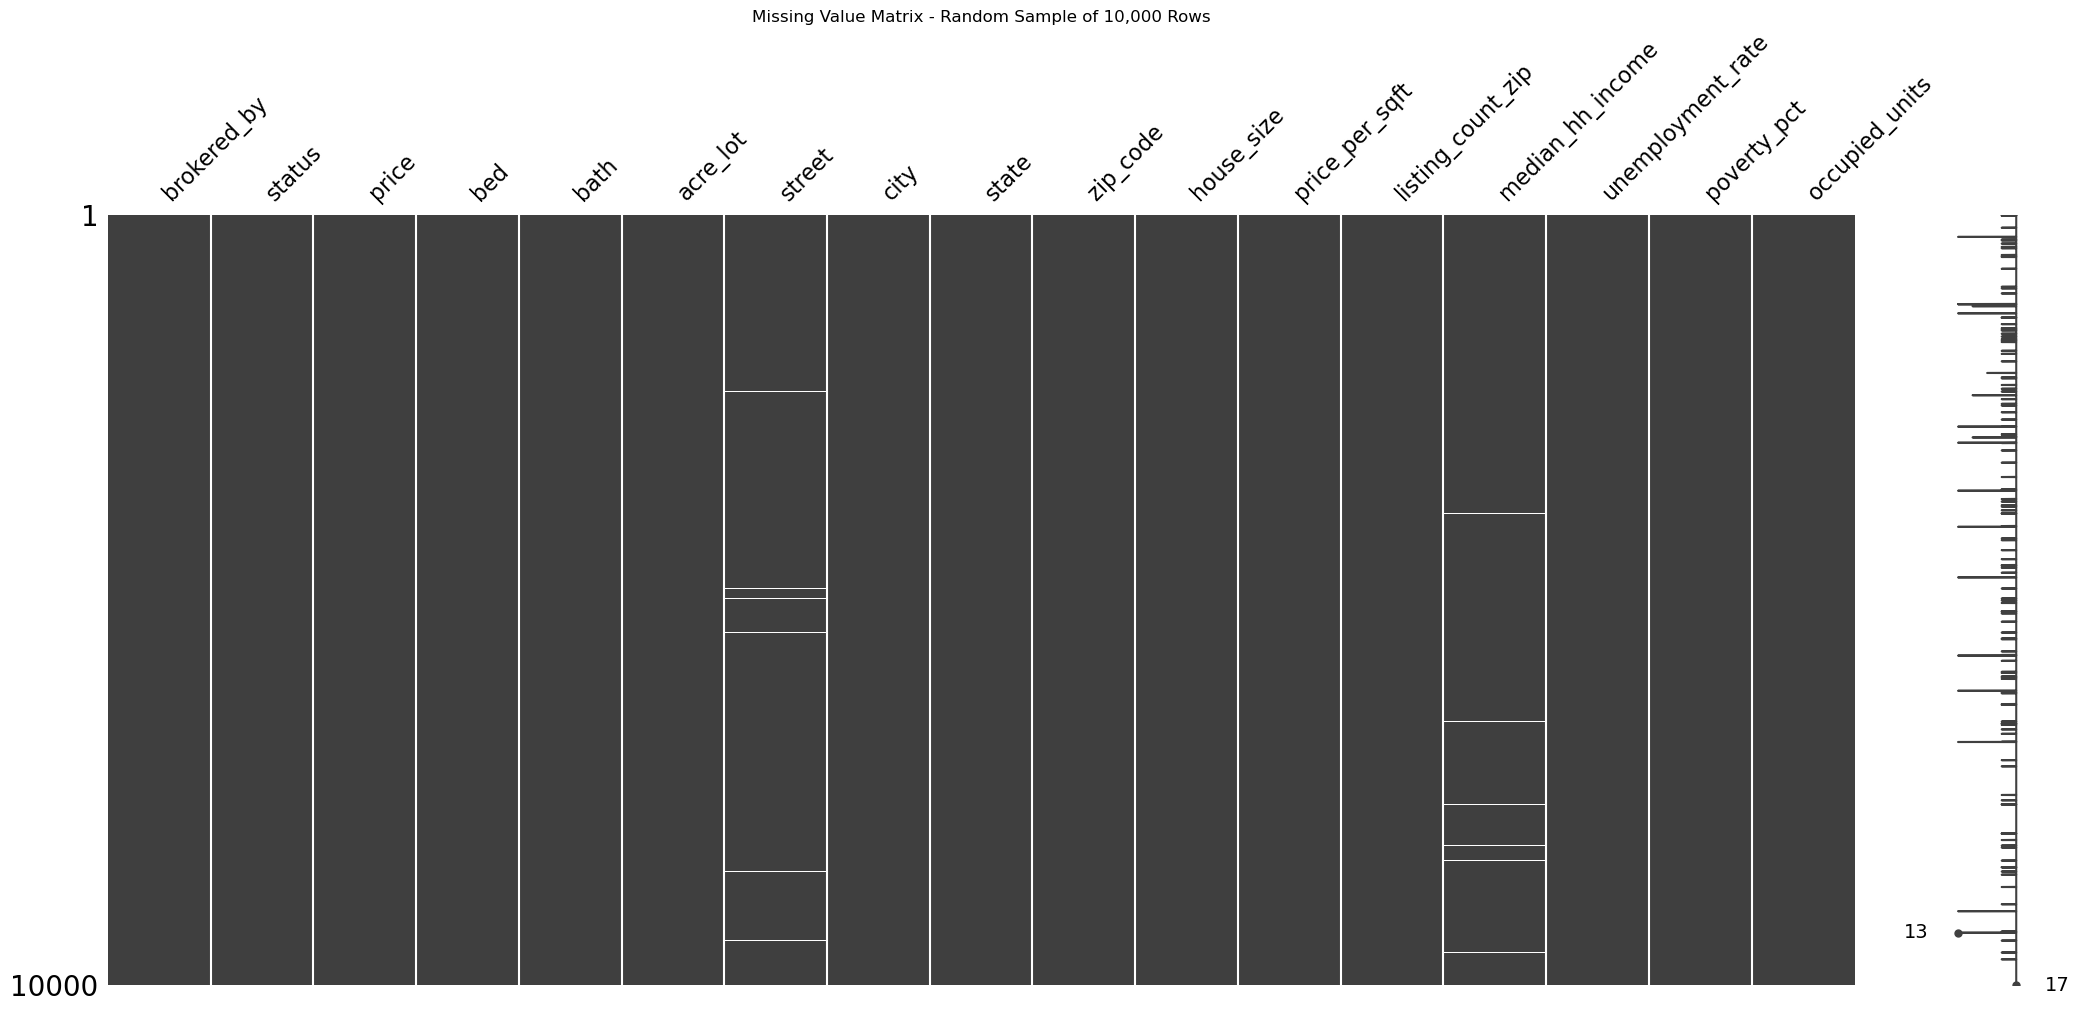

In [153]:
msno.matrix(df.sample(10000, random_state=42))
plt.title('Missing Value Matrix - Random Sample of 10,000 Rows')
plt.show()

The missing value matrix shows one row per listing and one column per variable where dark gray means the value is present and white gaps mean it is missing. Almost every column is solid, confirming the data is clean after wrangling. The street column has a few scattered gaps, and the Census columns show missing values in the same rows because when a ZIP code did not match a Census record, all of the Census fields are missing together for that listing. Since these gaps affect less than 1% of listings, they will not meaningfully affect the analysis.

## 8. Exploratory Data Analysis

In this section I investigate every feature using histograms, scatter plots, bar charts and box plots. The goal is to understand how each feature is distributed and how it relates to the listing price.

### Price Distribution

I look at the distribution of listing price both in its raw form and after applying a log transformation. Price is heavily skewed to the right so the log version is easier to read and will be more useful for modeling.

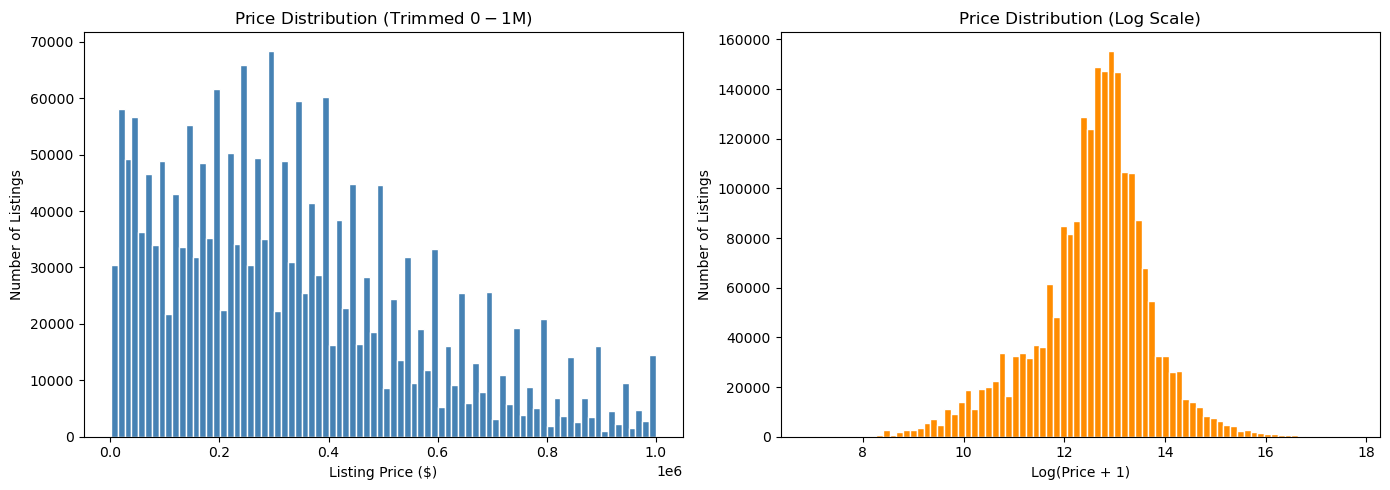

Median price: $325,000
Mean price: $515,234
Skewness (raw): 15.45
Skewness (log): -0.57


In [157]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trim to homes priced $0 to $1M so the shape is easy to see
price_trimmed = df[df['price'] <= 1_000_000]['price']
axes[0].hist(price_trimmed, bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Listing Price ($)')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('Price Distribution (Trimmed $0 - $1M)')

axes[1].hist(np.log1p(df['price']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_xlabel('Log(Price + 1)')
axes[1].set_ylabel('Number of Listings')
axes[1].set_title('Price Distribution (Log Scale)')

plt.tight_layout()
plt.show()

print(f"Median price: ${df['price'].median():,.0f}")
print(f"Mean price: ${df['price'].mean():,.0f}")
print(f"Skewness (raw): {df['price'].skew():.2f}")
print(f"Skewness (log): {np.log1p(df['price']).skew():.2f}")

The left chart shows the price distribution trimmed to 0–1M so the shape is easy to see, and it is extremely right skewed, most listings are clustered at lower prices while a few are very expensive. The log transformation on the right makes the distribution much more symmetric and bell-shaped. This is confirmed by the skewness dropping from 15.45 raw to -0.57 after the log transform. For modeling I will use the log-transformed price as my target variable. The median price of around 325,000 is a better representation of a typical home than the mean of $515,234, which is pulled up by luxury listings.

### House Size Distribution

I look at the distribution of house size in square feet to understand the range and shape of this important feature.

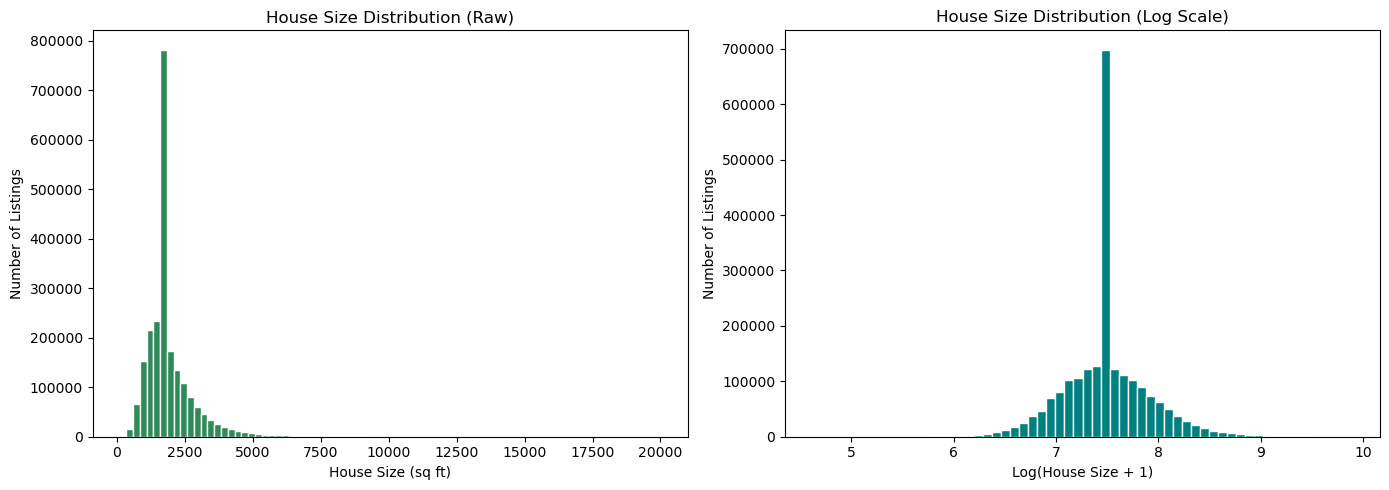

Median house size: 1,760 sq ft
Mean house size: 1,954 sq ft
Skewness: 4.10


In [160]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['house_size'], bins=80, color='seagreen', edgecolor='white')
axes[0].set_xlabel('House Size (sq ft)')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('House Size Distribution (Raw)')
axes[1].hist(np.log1p(df['house_size']), bins=60, color='teal', edgecolor='white')
axes[1].set_xlabel('Log(House Size + 1)')
axes[1].set_ylabel('Number of Listings')
axes[1].set_title('House Size Distribution (Log Scale)')
plt.tight_layout()
plt.show()
print(f"Median house size: {df['house_size'].median():,.0f} sq ft")
print(f"Mean house size: {df['house_size'].mean():,.0f} sq ft")
print(f"Skewness: {df['house_size'].skew():.2f}")

House size is right skewed with a skewness of 4.10. Most homes cluster around 1,500 to 2,500 square feet with a long tail stretching toward very large properties. The median is 1,760 square feet while the mean is higher at 1,954, which confirms that a small number of very large homes pull the average upward. The log transformation on the right pulls the tail in and makes the distribution much more symmetric, which is why log transformed size may work better in the modeling phase. The tall spike in both charts is the large group of listings that share the most common home size.

### Bedrooms and Bathrooms

I look at the count distributions for bedrooms and bathrooms to see which configurations are most common.

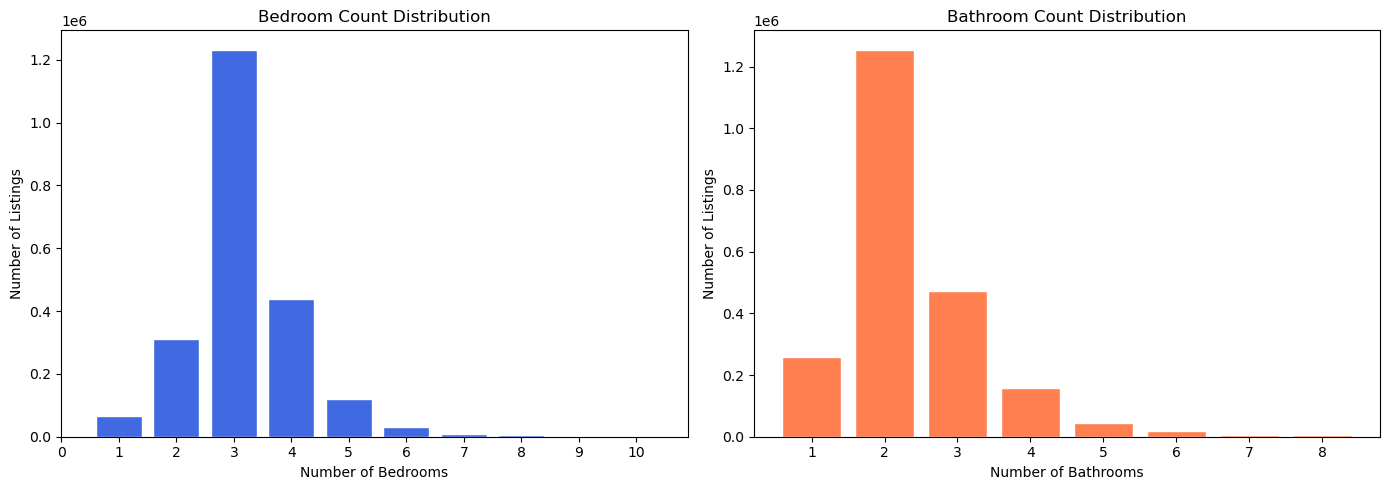

Most common bedrooms: 3
Most common bathrooms: 2


In [163]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bed_counts = df['bed'].value_counts().sort_index()
bed_counts = bed_counts[bed_counts.index <= 10]
axes[0].bar(bed_counts.index, bed_counts.values, color='royalblue', edgecolor='white')
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Number of Listings')
axes[0].set_title('Bedroom Count Distribution')
axes[0].set_xticks(range(0, 11))
bath_counts = df['bath'].value_counts().sort_index()
bath_counts = bath_counts[bath_counts.index <= 8]
axes[1].bar(bath_counts.index, bath_counts.values, color='coral', edgecolor='white')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('Number of Listings')
axes[1].set_title('Bathroom Count Distribution')
plt.tight_layout()
plt.show()
print(f"Most common bedrooms: {df['bed'].mode()[0]:.0f}")
print(f"Most common bathrooms: {df['bath'].mode()[0]:.0f}")

The most common listing is a 3 bedroom home with about 1.2 million listings, followed by 4-bedroom with roughly 430,000. Bathrooms peak at 2, with 3 bathrooms as the second most common. Both distributions are left skewed, meaning counts drop off sharply after the peak. Very few listings have more than 5 bedrooms or 4 bathrooms. This matches what we would expect for a US residential real estate dataset, where the typical family home has 3 bedrooms and 2 bathrooms.

### Listing Status

I look at how many listings fall into each status category to understand the makeup of my dataset.

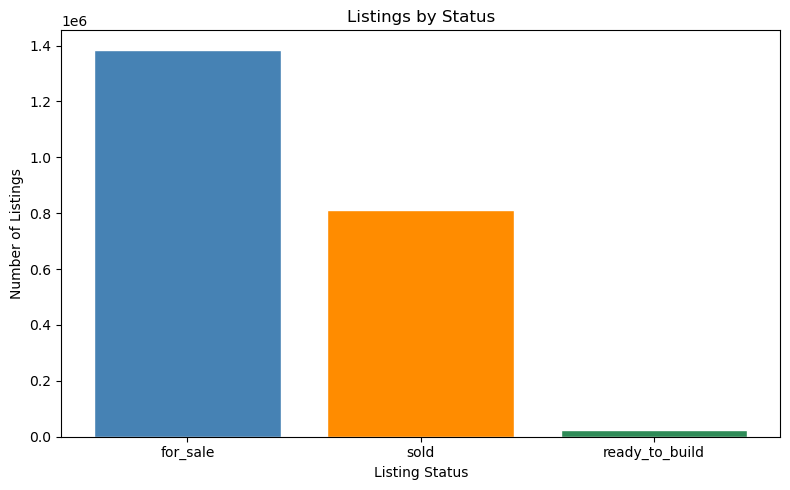

for_sale: 1,385,403 (62.4%)
sold: 811,279 (36.5%)
ready_to_build: 24,446 (1.1%)


In [166]:
status_counts = df['status'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(status_counts.index, status_counts.values, color=['steelblue', 'darkorange', 'seagreen'], edgecolor='white')
plt.xlabel('Listing Status')
plt.ylabel('Number of Listings')
plt.title('Listings by Status')
plt.tight_layout()
plt.show()
for status, count in status_counts.items():
    print(f"{status}: {count:,} ({count/len(df)*100:.1f}%)")

Active For Sale listings make up the majority of the dataset at 1,385,403 listings (62.4%), followed by Sold listings at 811,279 (36.5%). Ready to Build listings, which are vacant lots rather than existing homes, make up only 24,446 listings (1.1%). Since For Sale and Sold together account for nearly 99% of the data, I focus my analysis on those two categories. Ready to Build listings are excluded from the price comparisons because land pricing works differently than pricing an existing home.

### Price vs House Size

I look at the relationship between house size and price using a scatter plot. This is one of the most important bivariate relationships since bigger homes should cost more.

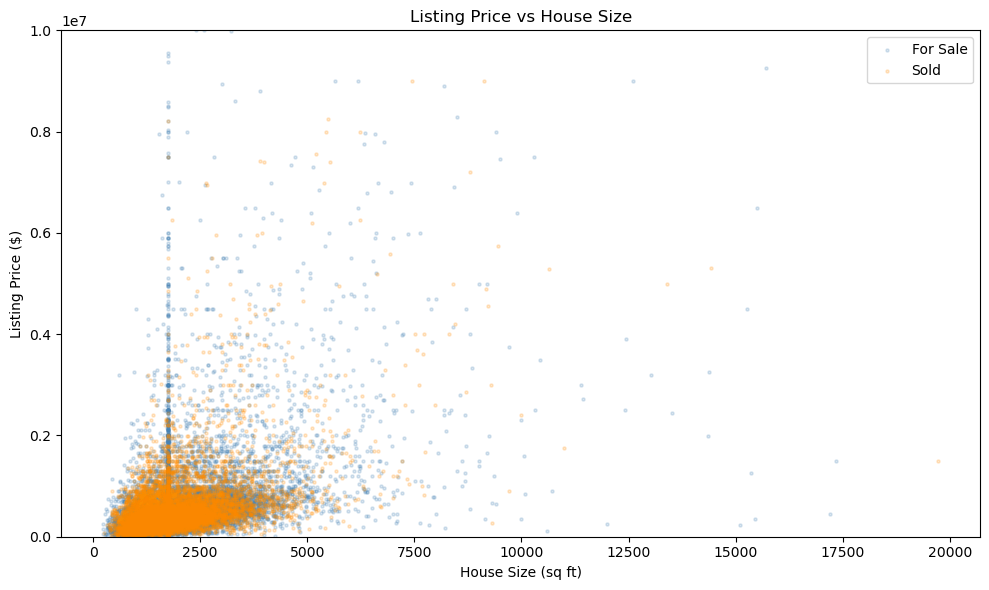

Pearson correlation between price and house_size: 0.402


In [169]:
# Plot for_sale and sold in two different colors
sample = df[df['status'].isin(['for_sale', 'sold'])].sample(30000, random_state=42)

plt.figure(figsize=(10, 6))
for status, color, label in zip(['for_sale', 'sold'], ['steelblue', 'darkorange'], ['For Sale', 'Sold']):
    subset = sample[sample['status'] == status]
    plt.scatter(subset['house_size'], subset['price'], alpha=0.2, s=5, color=color, label=label)

plt.xlabel('House Size (sq ft)')
plt.ylabel('Listing Price ($)')
plt.title('Listing Price vs House Size')
plt.ylim(0, 10000000)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Pearson correlation between price and house_size: {df['price'].corr(df['house_size']):.3f}")

There is a positive relationship between house size and listing price. Larger homes generally cost more. For Sale (blue) and Sold (orange) listings follow the same pattern. I capped the y axis at $10M so the higher priced listings are included while the most extreme outliers are cut off. Most listings cluster below 5,000 square feet and under 1M, with the price spread widening as homes get larger. The vertical line of points near 2,000 square feet reflects the many listings that share that common home size. The wide scatter shows that two homes of the same size can have very different prices depending on location, which is why I also include ZIP code income and state in my analysis.

### Price vs Bedrooms

I compare median listing price across different bedroom counts to see how bedrooms affect price.

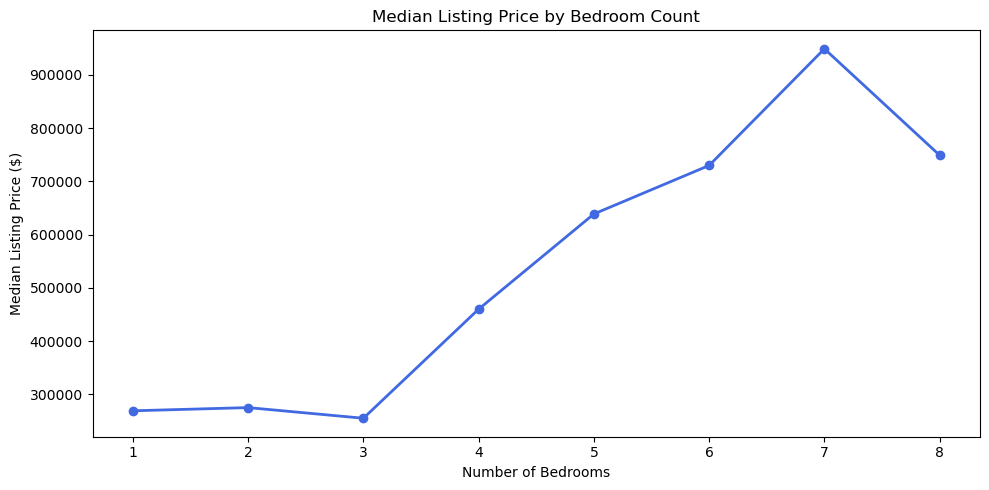

 bed    price
 1.0 269000.0
 2.0 275000.0
 3.0 255000.0
 4.0 459900.0
 5.0 638726.5
 6.0 729900.0
 7.0 949000.0
 8.0 749000.0


In [172]:
df_bed = df[df['bed'] <= 8]
bed_price = df_bed.groupby('bed')['price'].median().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(bed_price['bed'], bed_price['price'], color='royalblue', marker='o', linewidth=2)
plt.xlabel('Number of Bedrooms')
plt.ylabel('Median Listing Price ($)')
plt.title('Median Listing Price by Bedroom Count')
plt.tight_layout()
plt.show()

print(bed_price.to_string(index=False))

Median price generally increases with bedroom count as expected. The relationship is not perfectly linear which makes sense because studio and 1 bedroom units in high cost urban markets can be priced higher than a 3-bedroom home in a rural area.

### Price vs Median Household Income

I look at how ZIP-level median household income relates to listing price. Wealthier ZIP codes should have higher prices.

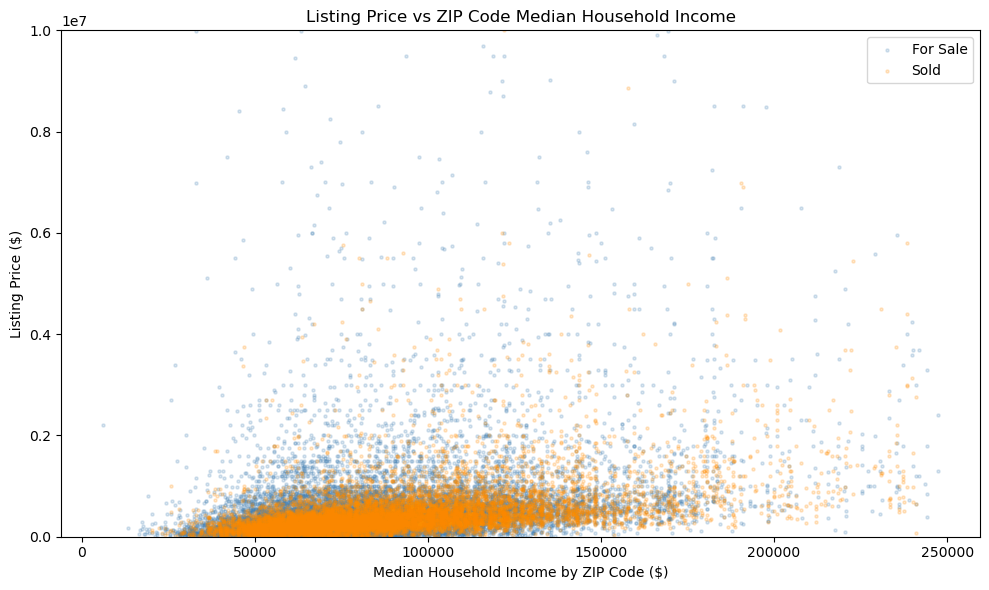

Pearson correlation between price and median_hh_income: 0.277


In [175]:
# Only use for_sale and sold listings, plotted in two different colors
df_inc = df[df['median_hh_income'].notna() & df['status'].isin(['for_sale', 'sold'])].sample(30000, random_state=42)

plt.figure(figsize=(10, 6))
for status, color, label in zip(['for_sale', 'sold'], ['steelblue', 'darkorange'], ['For Sale', 'Sold']):
    subset = df_inc[df_inc['status'] == status]
    plt.scatter(subset['median_hh_income'], subset['price'], alpha=0.2, s=5, color=color, label=label)

plt.xlabel('Median Household Income by ZIP Code ($)')
plt.ylabel('Listing Price ($)')
plt.title('Listing Price vs ZIP Code Median Household Income')
plt.ylim(0, 10000000)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Pearson correlation between price and median_hh_income: {df['price'].corr(df['median_hh_income']):.3f}")

There is a clear positive relationship between ZIP code income and listing price. Homes in wealthier ZIP codes cost more. For Sale (blue) and Sold (orange) listings follow the same trend. I capped the y axis at 10M so the main cluster of listings is easy to see. This confirms that adding Census income data will help predict price.

### Median Price by State

I aggregate median price to the state level and plot the top 30 states by listing volume to compare markets.

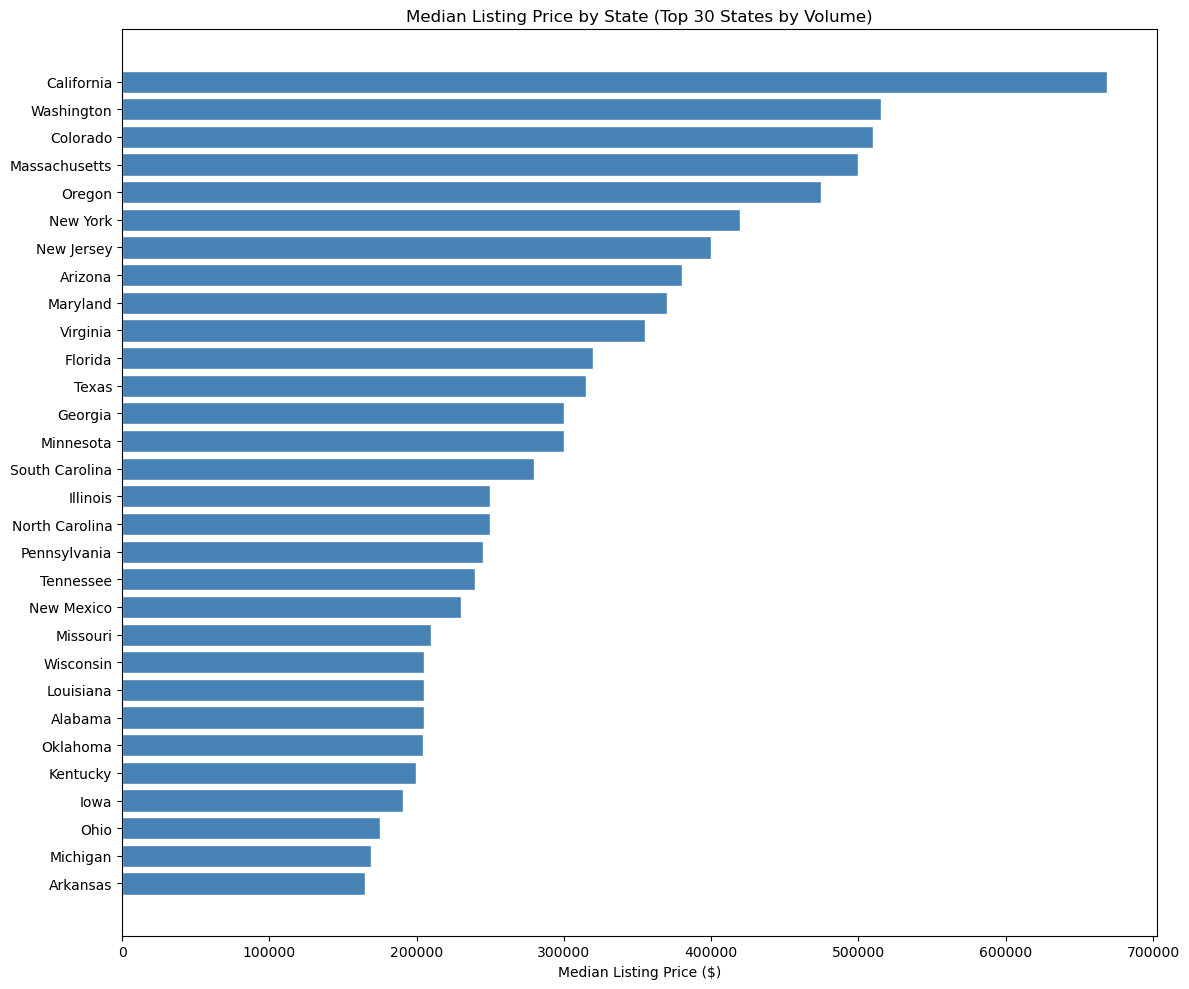

Top 10 most expensive states by median price:
               state  median_price  listing_count
              Hawaii      670000.0           7198
          California      669000.0         226706
District of Columbia      649900.0           6618
                Utah      544775.0          14533
          Washington      515000.0          62404
            Colorado      510000.0          32174
       Massachusetts      499999.0          38003
               Idaho      479850.0          16668
              Oregon      474500.0          32106
              Nevada      449900.0          14641


In [178]:
state_stats = df.groupby('state').agg(
    median_price=('price', 'median'),
    listing_count=('price', 'count'),
    median_ppsf=('price_per_sqft', 'median')
).reset_index()
top_states = state_stats.sort_values('listing_count', ascending=False).head(30)
top_states_price = top_states.sort_values('median_price', ascending=True)
plt.figure(figsize=(12, 10))
plt.barh(top_states_price['state'], top_states_price['median_price'], color='steelblue', edgecolor='white')
plt.xlabel('Median Listing Price ($)')
plt.title('Median Listing Price by State (Top 30 States by Volume)')
plt.tight_layout()
plt.show()
print("Top 10 most expensive states by median price:")
print(state_stats.sort_values('median_price', ascending=False).head(10)[['state', 'median_price', 'listing_count']].to_string(index=False))

Hawaii, California and the District of Columbia have the highest median listing prices. Southern and Midwestern states have much lower prices. This confirms that state level location is one of the strongest drivers of listing price and should be included as a feature in my regression model.

### Price Per Square Foot by State

Price per square foot is a better value comparison metric because it controls for property size.

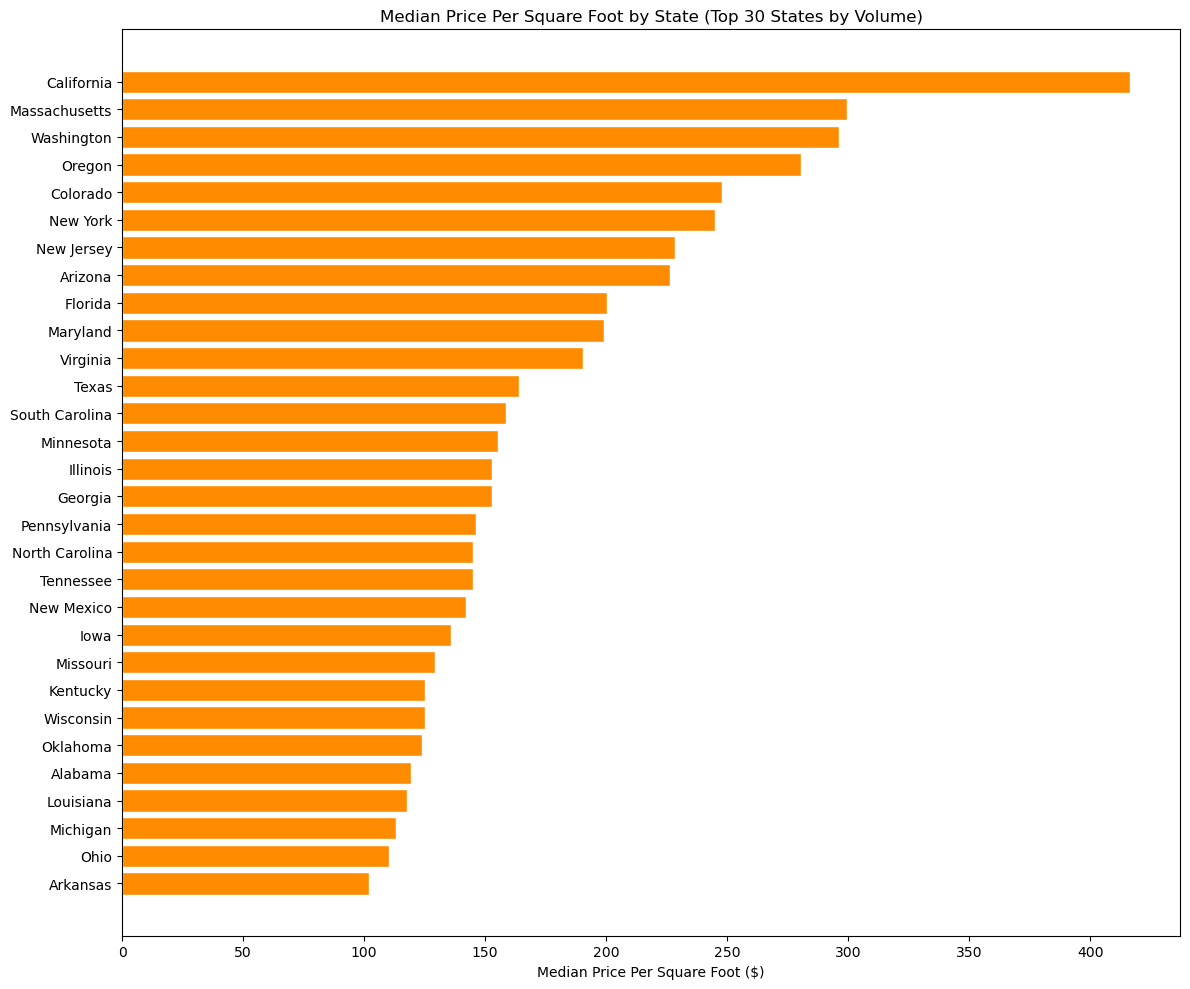

Top 10 states by price per square foot:
               state  median_ppsf  median_price
              Hawaii      569.885      670000.0
District of Columbia      534.320      649900.0
          California      416.180      669000.0
       Massachusetts      299.360      499999.0
          Washington      296.150      515000.0
              Oregon      280.455      474500.0
              Nevada      263.510      449900.0
                Guam      259.400      360000.0
               Idaho      253.610      479850.0
            Colorado      247.920      510000.0


In [181]:
top_states_ppsf = top_states.sort_values('median_ppsf', ascending=True)

plt.figure(figsize=(12, 10))
plt.barh(top_states_ppsf['state'], top_states_ppsf['median_ppsf'], color='darkorange', edgecolor='white')
plt.xlabel('Median Price Per Square Foot ($)')
plt.title('Median Price Per Square Foot by State (Top 30 States by Volume)')
plt.tight_layout()
plt.show()

print("Top 10 states by price per square foot:")
print(state_stats.sort_values('median_ppsf', ascending=False).head(10)[['state', 'median_ppsf', 'median_price']].to_string(index=False))

Hawaii, the District of Columbia and California have the highest price per square foot because land value is extremely high in those markets. Buyers in these places pay a premium for location not just size. States like Arkansas, Ohio and Michigan offer much more square footage per dollar which matters to investors looking for value.

### Domestic Migration Trends by State

These tables track how many people moved between states each year. For each state and year I calculate net migration — the number of people who moved in from other states minus the number who moved out. States gaining people have growing housing demand which pushes prices up, while states losing people may see softer demand. Tracking this across 2019 to 2024 shows which states are consistently gaining or losing momentum, which connects directly to my goal of predicting which markets will appreciate over the next 5 years. Note: 2020 is not available because the Census did not publish standard migration flows that year due to the pandemic.

In [184]:
def net_migration_wide(filepath):
    raw = pd.read_excel(filepath, header=None)
    origin_cols = {}
    for c in range(9, raw.shape[1]):
        name = raw.iloc[6, c]
        if isinstance(name, str) and name.strip() != 'Total':
            origin_cols[name.strip()] = c
    states = []
    for r in range(9, raw.shape[0]):
        name = raw.iloc[r, 0]
        if isinstance(name, str) and name.strip() in origin_cols:
            states.append((name.strip(), r))
    rows = []
    for state, r in states:
        inflow = pd.to_numeric(raw.iloc[r, 7], errors='coerce')
        c = origin_cols[state]
        col_vals = pd.to_numeric(raw.iloc[[r2 for _, r2 in states], c], errors='coerce')
        outflow = col_vals.sum()
        rows.append({'state': state, 'net_migration': inflow - outflow})
    return pd.DataFrame(rows)

def net_migration_long(filepath, valid_states):
    raw = pd.read_excel(filepath, header=None, skiprows=8)
    raw.columns = ['current', 'origin', 'estimate', 'moe']
    raw['estimate'] = pd.to_numeric(raw['estimate'], errors='coerce')
    raw = raw.dropna(subset=['estimate'])
    raw = raw[raw['current'].isin(valid_states) & raw['origin'].isin(valid_states)]
    raw = raw[raw['current'] != raw['origin']]
    inflow = raw.groupby('current')['estimate'].sum()
    outflow = raw.groupby('origin')['estimate'].sum()
    net = (inflow - outflow).reset_index()
    net.columns = ['state', 'net_migration']
    return net

migration_2019 = net_migration_wide('State_to_State_Migrations_Table_2019.xls')
migration_2021 = net_migration_wide('State_to_State_Migrations_Table_2021.xls')
migration_2022 = net_migration_wide('State_to_State_Migration_Table_2022_T13_updated_2024_06_27.xlsx')
migration_2023 = net_migration_wide('State_to_State_Migration_Table_2023_T13.xlsx')

valid_states = set(migration_2023['state'])
migration_2024 = net_migration_long('State_to_State_Migration_Table_2024_T13.xlsx', valid_states)

migration = migration_2019.rename(columns={'net_migration': 2019})
for yr, m in [(2021, migration_2021), (2022, migration_2022), (2023, migration_2023), (2024, migration_2024)]:
    migration = migration.merge(m.rename(columns={'net_migration': yr}), on='state')

print(migration.sort_values(2024, ascending=False).head(10).to_string(index=False))

         state     2019     2021     2022     2023    2024
         Texas 105837.0 142722.0 170649.0 131120.0 74219.0
       Florida 134310.0 196948.0 240271.0 122674.0 66720.0
North Carolina  58648.0  98895.0  81920.0 106071.0 57191.0
       Arizona  79554.0  88165.0  77759.0  62168.0 55409.0
South Carolina  46392.0  79041.0  65120.0  68353.0 54776.0
        Nevada  27593.0  40386.0  13275.0  17542.0 39869.0
       Georgia  30397.0  63741.0  72878.0  57520.0 37089.0
     Tennessee  40207.0  68777.0  43246.0  22456.0 36152.0
      Oklahoma  16245.0  37070.0  32006.0  23370.0 34070.0
       Alabama   5935.0  11113.0  36369.0  19625.0 22450.0


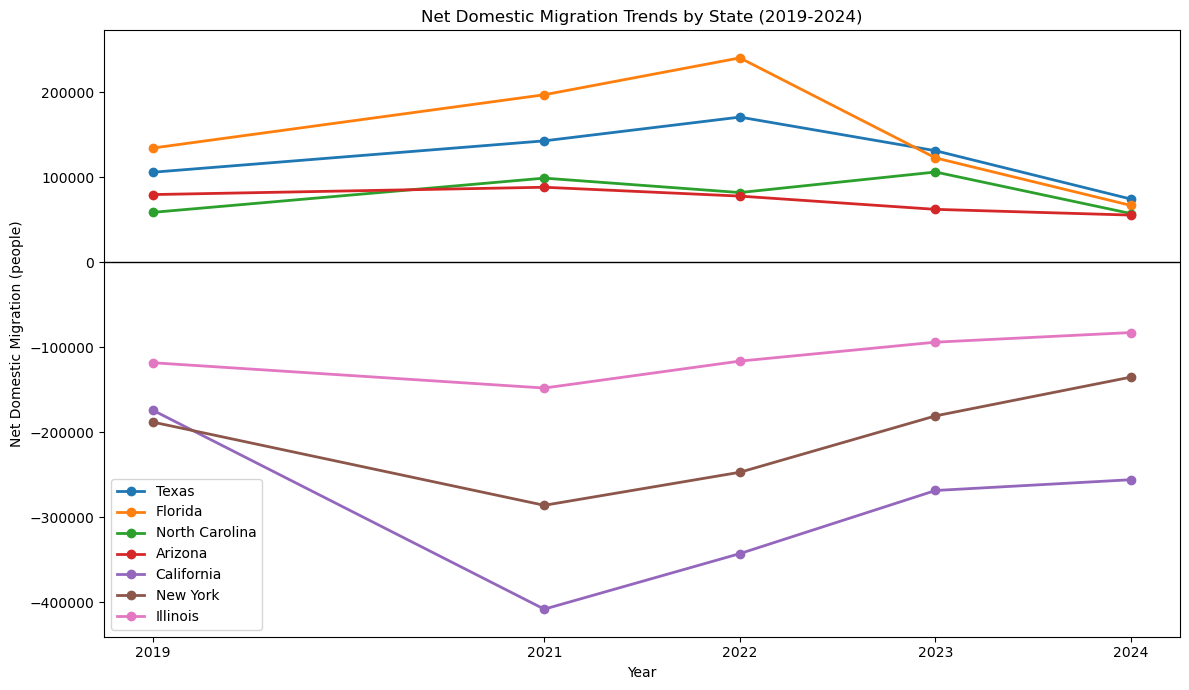

In [185]:
top_states = ['Texas', 'Florida', 'North Carolina', 'Arizona', 'California', 'New York', 'Illinois']
years = [2019, 2021, 2022, 2023, 2024]

plt.figure(figsize=(12, 7))
for state in top_states:
    values = migration[migration['state'] == state][years].values.flatten()
    plt.plot(years, values, marker='o', linewidth=2, label=state)

plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Year')
plt.ylabel('Net Domestic Migration (people)')
plt.title('Net Domestic Migration Trends by State (2019-2024)')
plt.legend()
plt.xticks(years)
plt.tight_layout()
plt.show()

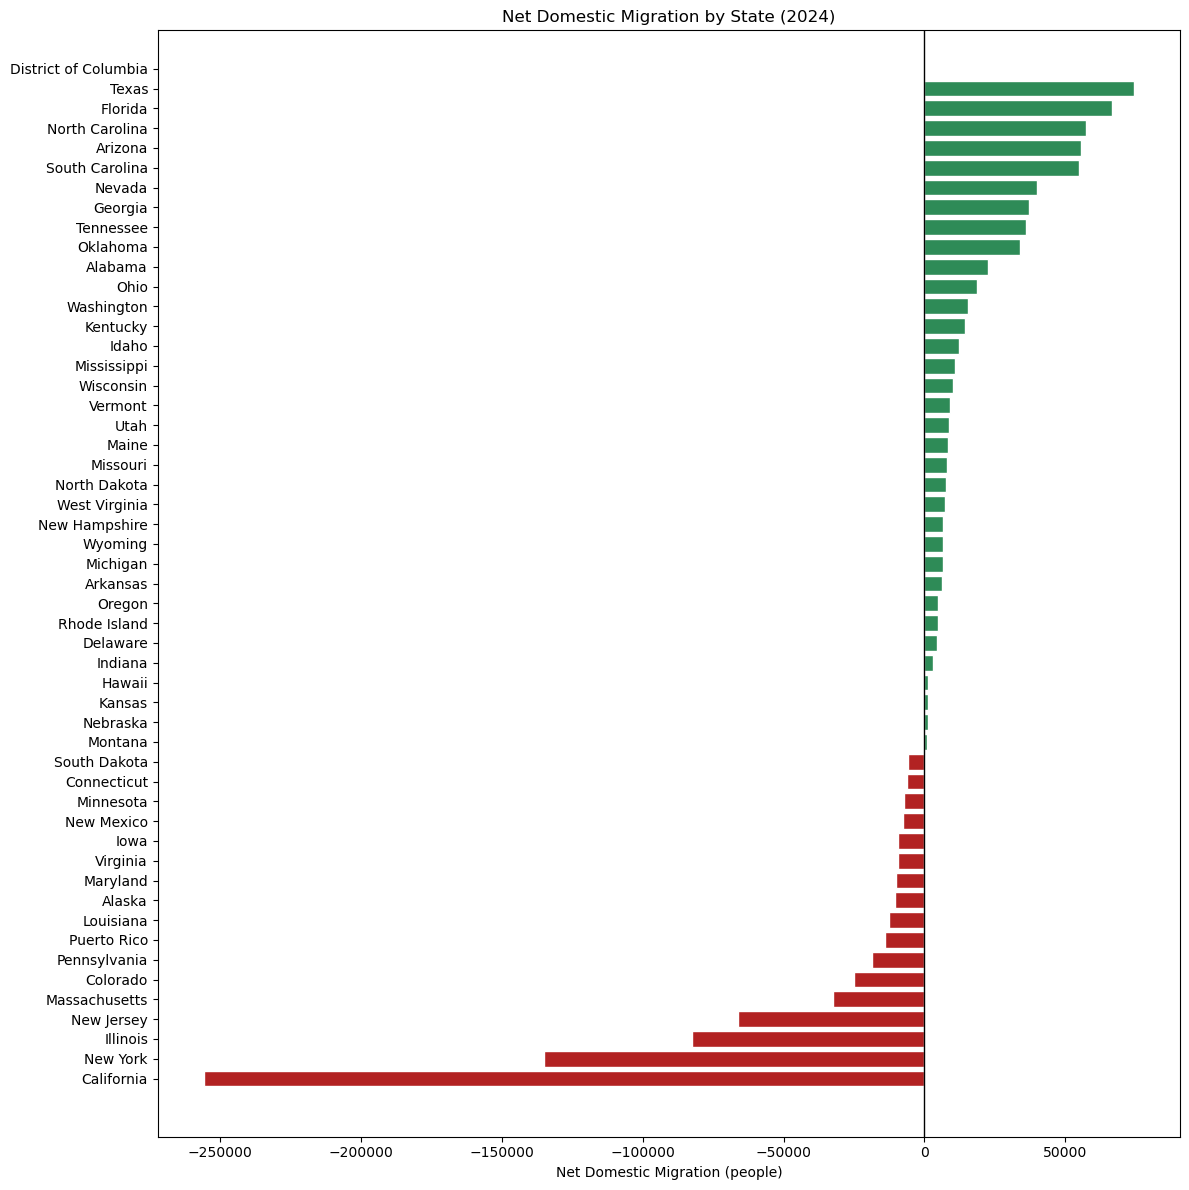

In [186]:
mig_sorted = migration.sort_values(2024)

plt.figure(figsize=(12, 12))
bar_colors = ['seagreen' if x > 0 else 'firebrick' for x in mig_sorted[2024]]
plt.barh(mig_sorted['state'], mig_sorted[2024], color=bar_colors, edgecolor='white')
plt.xlabel('Net Domestic Migration (people)')
plt.title('Net Domestic Migration by State (2024)')
plt.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

### Correlation Heatmap

I calculate Pearson correlation coefficients between all numeric features and display them as a heatmap. This shows which features are most strongly related to price and which features are correlated with each other.

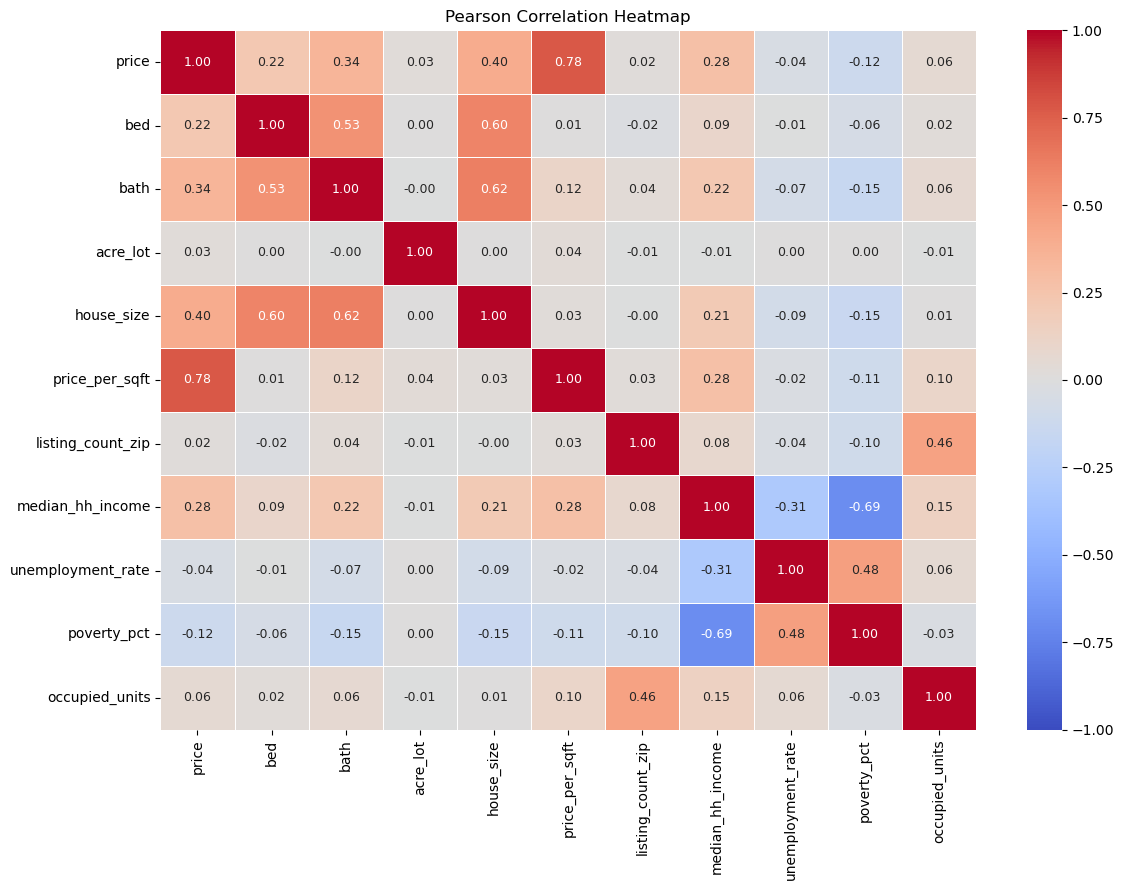

In [188]:
import seaborn as sns

numeric_cols = ['price', 'bed', 'bath', 'acre_lot', 'house_size',
                'price_per_sqft', 'listing_count_zip',
                'median_hh_income', 'unemployment_rate', 'poverty_pct', 'occupied_units']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
plt.title('Pearson Correlation Heatmap')
plt.tight_layout()
plt.show()

### Box Plots- For Sale vs Sold

A box plot shows the median (the line in the middle), the typical range of prices (the box), and outliers (the dots). Here I compare For Sale listings against Sold listings so it is clear what the chart is showing. The two boxes are colored differently to make them easy to tell apart.

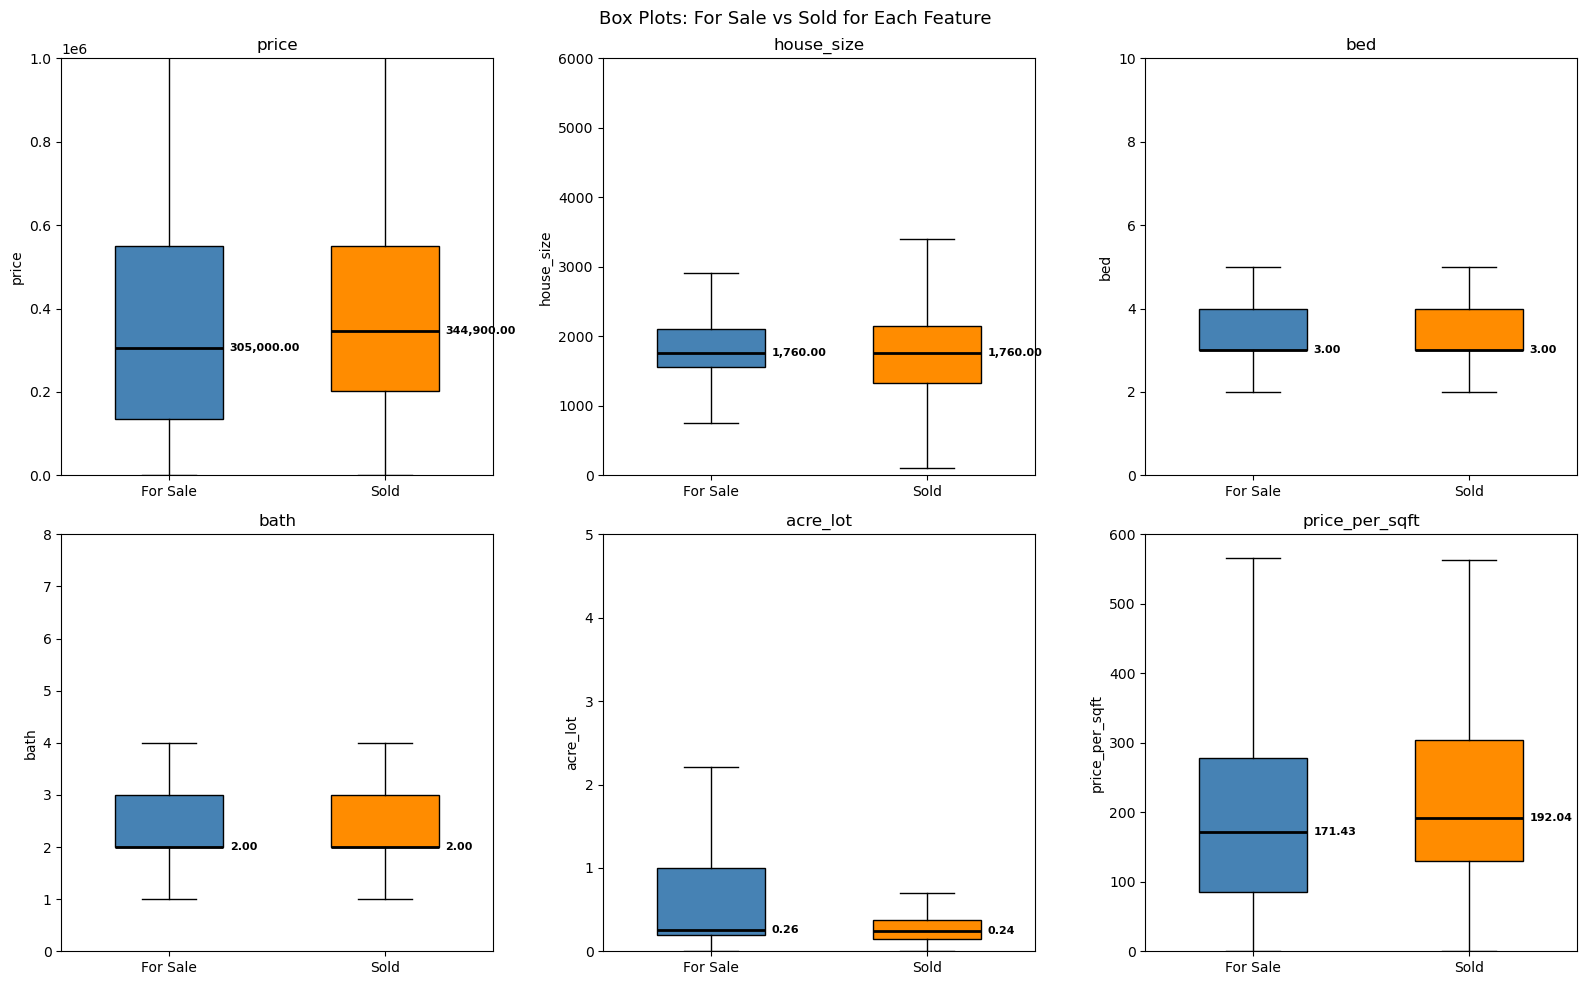

Median price For Sale: $ 305,000
Median price Sold:     $ 344,900
Median house size:       1,760 sq ft
Median bedrooms:         3
Median bathrooms:        2
Median lot size:         0.26 acres
Median price per sq ft: $ 180


In [191]:
df_status = df[df['status'].isin(['for_sale', 'sold'])]

cols = ['price', 'house_size', 'bed', 'bath', 'acre_lot', 'price_per_sqft']
limits = [1000000, 6000, 10, 8, 5, 600]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col, lim in zip(axes, cols, limits):
    for_sale_vals = df_status[df_status['status'] == 'for_sale'][col].dropna()
    sold_vals = df_status[df_status['status'] == 'sold'][col].dropna()
    box = ax.boxplot([for_sale_vals, sold_vals], tick_labels=['For Sale', 'Sold'],
                     patch_artist=True, showfliers=False, widths=0.5,
                     medianprops=dict(color='black', linewidth=2))
    box['boxes'][0].set_facecolor('steelblue')
    box['boxes'][1].set_facecolor('darkorange')
    ax.set_ylim(0, lim)
    ax.set_title(col)
    ax.set_ylabel(col)
    for i, data in enumerate([for_sale_vals, sold_vals], start=1):
        med = data.median()
        ax.text(i + 0.28, med, f'{med:,.2f}', va='center', fontsize=8, fontweight='bold')

fig.suptitle('Box Plots: For Sale vs Sold for Each Feature', fontsize=13)
plt.tight_layout()
plt.show()

for_sale = df_status[df_status['status'] == 'for_sale']['price']
sold = df_status[df_status['status'] == 'sold']['price']

print("Median price For Sale: $", f"{for_sale.median():,.0f}")
print("Median price Sold:     $", f"{sold.median():,.0f}")
print("Median house size:      ", f"{df['house_size'].median():,.0f} sq ft")
print("Median bedrooms:        ", f"{df['bed'].median():.0f}")
print("Median bathrooms:       ", f"{df['bath'].median():.0f}")
print("Median lot size:        ", f"{df['acre_lot'].median():.2f} acres")
print("Median price per sq ft: $", f"{df['price_per_sqft'].median():,.0f}")

Each panel compares For Sale listings in blue to Sold listings in orange for one feature. The box shows the middle 50 percent of values, the black line marks the median, and the printed number labels each median. I capped the y axis on each chart so the boxes are visible. Sold homes have a slightly higher median price of 344,900 dollars versus 305,000 dollars for active For Sale listings, but the two groups look nearly identical on house size, bedrooms, bathrooms, lot size, and price per square foot. This tells me that sold and active listings are structurally similar homes, and the price gap comes from market conditions rather than differences in the properties themselves.

## 9. Final Dataset Summary

I display the final information about my cleaned and merged dataset to confirm it is ready for the modeling phase.

In [194]:
print(df.info())
print("\nFinal shape:", df.shape)
print("\nColumns:", df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2221128 entries, 0 to 2221127
Data columns (total 17 columns):
 #   Column             Dtype  
---  ------             -----  
 0   brokered_by        float64
 1   status             object 
 2   price              float64
 3   bed                float64
 4   bath               float64
 5   acre_lot           float64
 6   street             float64
 7   city               object 
 8   state              object 
 9   zip_code           object 
 10  house_size         float64
 11  price_per_sqft     float64
 12  listing_count_zip  int64  
 13  median_hh_income   float64
 14  unemployment_rate  float64
 15  poverty_pct        float64
 16  occupied_units     float64
dtypes: float64(12), int64(1), object(4)
memory usage: 288.1+ MB
None

Final shape: (2221128, 17)

Columns: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'price_per_sqft', 'listing_count_zip', 'median_hh_income

In [195]:
print("Missing values in final dataset:")
print(df.isnull().sum())

Missing values in final dataset:
brokered_by           4511
status                   0
price                    0
bed                      0
bath                     0
acre_lot                 0
street               10610
city                  1297
state                    0
zip_code                 0
house_size               0
price_per_sqft           0
listing_count_zip        0
median_hh_income     15371
unemployment_rate     3800
poverty_pct           3285
occupied_units        2822
dtype: int64


In [196]:
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,price_per_sqft,listing_count_zip,median_hh_income,unemployment_rate,poverty_pct,occupied_units
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,00601,920.0,114.13,2,18571.0,21.5,61.2,5611.0
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,00601,1527.0,52.39,2,18571.0,21.5,61.2,5611.0
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,00795,748.0,89.57,16,23391.0,18.5,43.3,14801.0
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,00731,1800.0,80.56,21,16917.0,11.5,56.4,3741.0
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,00680,1760.0,36.93,47,17857.0,20.6,52.6,17584.0


In [197]:
df.tail()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,price_per_sqft,listing_count_zip,median_hh_income,unemployment_rate,poverty_pct,occupied_units
2221123,23009.0,sold,359900.0,4.0,2.0,0.33,353094.0,Richland,Washington,99354,3600.0,99.97,129,88601.0,4.8,10.5,10274.0
2221124,18208.0,sold,350000.0,3.0,2.0,0.10,1062149.0,Richland,Washington,99354,1616.0,216.58,129,88601.0,4.8,10.5,10274.0
2221125,76856.0,sold,440000.0,6.0,3.0,0.50,405677.0,Richland,Washington,99354,3200.0,137.50,129,88601.0,4.8,10.5,10274.0
2221126,53618.0,sold,179900.0,2.0,1.0,0.09,761379.0,Richland,Washington,99354,933.0,192.82,129,88601.0,4.8,10.5,10274.0
2221127,108243.0,sold,580000.0,5.0,3.0,0.31,307704.0,Richland,Washington,99354,3615.0,160.44,129,88601.0,4.8,10.5,10274.0


In [198]:
df.to_csv('realtor_cleaned_merged.csv', index=False)
print(f"Saved: realtor_cleaned_merged.csv")
print(f"Shape: {df.shape}")

Saved: realtor_cleaned_merged.csv
Shape: (2221128, 17)


The cleaned and merged dataset is saved as realtor_cleaned_merged.csv and is ready for modeling. It has all the original listing columns plus the three derived features I created and the four Census economic columns joined by ZIP code.

## 10. Conclusion

Data Wrangling
* Loaded three data sources: 2,226,382 Realtor.com listings, two ACS Census tables covering over 33,000 ZIP codes, and five years of Census state to state migration tables.
* Dropped rows missing price, state, or ZIP code. Filled missing bed, bath, house size, and lot size with the median.
* Printed and removed 808 duplicate rows.
* Filtered out implausible prices and house sizes.
* Converted ZIP codes to 5 digit strings and pulled the correct Percent columns from DP03 so unemployment and poverty rates showed real values.
* Final cleaned dataset: 2,221,128 listings with a 99.3 percent Census match rate.
* Engineered three new features: price per square foot, listing count per ZIP code, and net domestic migration by state.

Key EDA Findings
* Price is heavily right skewed with a skewness of 15.45. The median is 325,000 dollars while the mean is 515,234 dollars. Log transforming price brings the skewness down to -0.57, so I will use log price as my modeling target.
* The typical listing is a 3 bedroom, 2 bathroom home of about 1,760 square feet priced at roughly 180 dollars per square foot.
* House size has the strongest property feature correlation with price at 0.40, followed by bathrooms at 0.34 and bedrooms at 0.22.
* ZIP code median household income correlates with price at 0.28. Hawaii, California, and the District of Columbia have the highest median prices and price per square foot.
* Prices stay flat from 1 to 3 bedrooms and only climb sharply starting at 4 bedrooms.
* Texas, Florida, North Carolina, and Arizona gained people every year from 2019 to 2024 while California, New York, and Illinois lost people every year. California lost over 255,000 net residents in 2024 alone.
* Bed, bath, and house size are correlated with each other, which I will handle with regularization during modeling.

Next Steps
* Pull ACS data for 2019 and 2023 at the ZIP level and calculate the change in median household income, educational attainment, and demographics between those years.
* Use that trajectory as new features showing how fast and in which direction each ZIP code is moving.
* Combine with the state migration trends to build a forward looking model that ranks ZIP codes by predicted appreciation over the next five years.
* The cleaned dataset is saved as realtor_cleaned_merged.csv and is ready for the modeling phase.